## 세종특별자치시 주차장 정보

### 라이브러리 Import

In [17]:
import pandas as pd
import time
import requests
import os
from dotenv import load_dotenv # API 키 관리를 위한 라이브러리
import matplotlib.pyplot as plt
import matplotlib

matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

### 데이터 프레임 생성

In [18]:
data_path = "../resources/parking_lot.csv"

df = pd.read_csv(data_path, encoding="CP949")
print(df.head())

    적재_연월   주차장 명칭 주차장 구분자 정보 주차장 유형 구분자 정보        주차장 위치 도로명주소정보  \
0  202603     나성노상         공영            노상       세종특별자치시 노을1로 16   
1  202603     도담노상         공영            노상     세종특별자치시 보듬3로 8-20   
2  202603     신안리1         공영            노외   세종특별자치시 조치원읍 장안길 14   
3  202603      원리1         공영            노상  세종특별자치시 조치원읍 으뜸길 122   
4  202603  조치원주차타워         공영            노외   세종특별자치시 조치원읍 새내로 99   

  주차장 위치 지번주소정보  주차장 주차 구획수 주차장 부제 시행 구분자 정보    주차장 운영요일 주차장 평일 운영시작시각  ...  \
0             -          33              미시행          평일          8:00  ...   
1             -          13              미시행          평일          8:00  ...   
2             -          49              미시행  평일+토요일+공휴일          7:00  ...   
3             -          36              미시행  평일+토요일+공휴일          7:00  ...   
4             -         200              미시행  평일+토요일+공휴일          8:00  ...   

  주차장 추가 단위요금 주차장 1일 주차권 요금 적용시간 주차장 1일 주차권 요금 주차장 월 정기권 요금 주차장 결제 방법 정보  \
0         500                  0  

### 필요한 컬럼 추출

In [19]:
cleaned_df = df[["주차장 명칭", "주차장 위치 도로명주소정보", "주차장 주차 구획수"]]
cleaned_df

,주차장 명칭,주차장 위치 도로명주소정보,주차장 주차 구획수
0,나성노상,세종특별자치시 노을1로 16,33
1,도담노상,세종특별자치시 보듬3로 8-20,13
2,신안리1,세종특별자치시 조치원읍 장안길 14,49
3,원리1,세종특별자치시 조치원읍 으뜸길 122,36
4,조치원주차타워,세종특별자치시 조치원읍 새내로 99,200
5,원리3,세종특별자치시 조치원읍 으뜸길 215,72
6,교리1,세종특별자치시 조치원읍 문화로 17,34
7,교리2,세종특별자치시 조치원읍 새내로 165,21
8,교리3,세종특별자치시 조치원읍 새내로 154-1,49
9,침산리13,세종특별자치시 조치원읍 문화2길 10,11


### API를 통한 지역 정보 매핑
API 정보: https://business.juso.go.kr/jst/jstRoadNmAddrApiSearch

In [ ]:
load_dotenv()
juso_api_key = os.getenv("JUSO_API_KEY")

def get_emd_name(address, api_key):
    url = "https://business.juso.go.kr/addrlink/addrLinkApi.do"

    params = {
        "currentPage": 1,
        "countPerPage": 1,
        "keyword": roadAddr,
        "confmKey": juso_api_key,
        "resultType": "json"
    }

    try:
        response = requests.get(url, params=params)

        if response.status_code == 200:
            data = response.json()
            juso_list = data.get("results", {}).get("juso", [])

        return juso_list[0].get("emdNm", "정보 없음") if juso_list else "정보 없음"
    
    except Exception as e:
        return f"오류({str(e)})"
    

cleaned_df['지역'] = cleaned_df['주차장 위치 도로명주소정보'].apply(lambda x: get_emd_name(x, juso_api_key))
cleaned_df.head()

,주차장 명칭,주차장 위치 도로명주소정보,주차장 주차 구획수,지역
0,나성노상,세종특별자치시 노을1로 16,33,한솔동
1,도담노상,세종특별자치시 보듬3로 8-20,13,도담동
2,신안리1,세종특별자치시 조치원읍 장안길 14,49,조치원읍
3,원리1,세종특별자치시 조치원읍 으뜸길 122,36,조치원읍
4,조치원주차타워,세종특별자치시 조치원읍 새내로 99,200,조치원읍


### API로 지역이 매핑되지 않는 경우 직접 매핑

In [21]:
missing_values = cleaned_df[cleaned_df['지역'] == "정보 없음"]
print(missing_values)

cleaned_df.loc[cleaned_df['주차장 명칭'] == "신흥리2", '지역'] = "조치원읍"
cleaned_df.loc[cleaned_df['주차장 명칭'] == "용포로공영주차장", '지역'] = "금남면" 
cleaned_df

      주차장 명칭         주차장 위치 도로명주소정보  주차장 주차 구획수     지역
18      신흥리2  세종특별자치시 조치원읍 신흥샛터길 37          28  정보 없음
44  용포로공영주차장                      -          55  정보 없음


,주차장 명칭,주차장 위치 도로명주소정보,주차장 주차 구획수,지역
0,나성노상,세종특별자치시 노을1로 16,33,한솔동
1,도담노상,세종특별자치시 보듬3로 8-20,13,도담동
2,신안리1,세종특별자치시 조치원읍 장안길 14,49,조치원읍
3,원리1,세종특별자치시 조치원읍 으뜸길 122,36,조치원읍
4,조치원주차타워,세종특별자치시 조치원읍 새내로 99,200,조치원읍
5,원리3,세종특별자치시 조치원읍 으뜸길 215,72,조치원읍
6,교리1,세종특별자치시 조치원읍 문화로 17,34,조치원읍
7,교리2,세종특별자치시 조치원읍 새내로 165,21,조치원읍
8,교리3,세종특별자치시 조치원읍 새내로 154-1,49,조치원읍
9,침산리13,세종특별자치시 조치원읍 문화2길 10,11,조치원읍


### 주차장 데이터 정리

In [22]:
# 세종시 지역 추출
region = pd.read_csv("../resources/illegal_summary.csv")["지역"]
region.head()

# 지역별 주차 구획수 합계 + 지역별 주차장 수
summary = cleaned_df.groupby('지역').agg({'주차장 명칭': 'count', '주차장 주차 구획수': 'sum'}).rename(columns={'주차장 명칭': '주차장수', '주차장 주차 구획수': '주차구획수'})

# region에 없는 지역을 주차장 수 0, 주차 구획수 0으로 추가
for r in region:
    if r not in summary.index:
        summary.loc[r] = [0, 0]
summary = summary.sort_index()
sorted_summary = summary.sort_values(by='주차구획수', ascending=False)
print(sorted_summary)
sorted_summary.to_csv("../resources/parking_summary.csv")

      주차장수  주차구획수
지역               
조치원읍    38   1299
나성동      4    882
보람동      4    238
아름동      1    236
종촌동      1    160
금남면      2     96
부강면      5     72
전의면      1     65
소담동      1     51
한솔동      1     33
도담동      1     13
연동면      1     10
전동면      0      0
장군면      0      0
가람동      0      0
집현동      0      0
한별동      0      0
연서면      0      0
소정면      0      0
연기면      0      0
어진동      0      0
고운동      0      0
세종동      0      0
새롬동      0      0
산울동      0      0
반곡동      0      0
대평동      0      0
다정동      0      0
해밀동      0      0


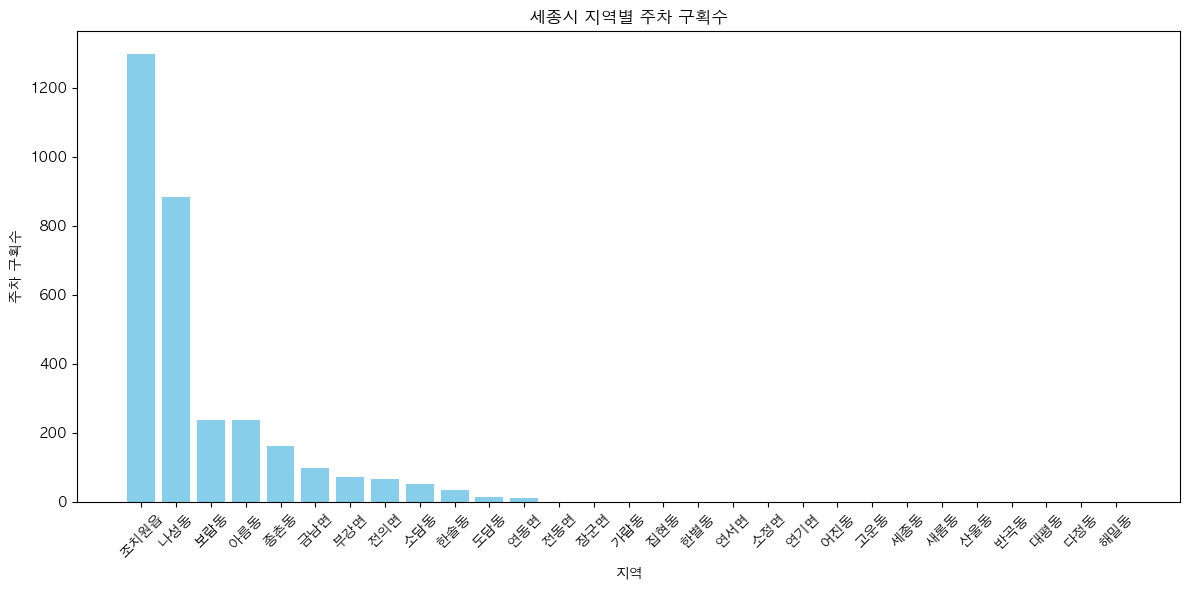

In [ ]:
# sorted_summary 시각화 
plt.figure(figsize=(12, 6))
plt.bar(sorted_summary.index, sorted_summary['주차구획수'], color='skyblue')
plt.xlabel('지역')
plt.ylabel('주차 구획수')
plt.title('세종시 지역별 주차 구획수')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
